# ORIE 4820 Capstone Project
## Optimizing Healthcare Insurance Outreach Across New York State Counties

**Objective:** Maximize the number of newly insured low-income individuals (age 21–64, income ≤ 200% FPL) by optimally allocating outreach resources across New York State counties, with an equity constraint ensuring underserved counties receive attention.

**Data Source:** U.S. Census Bureau Small Area Health Insurance Estimates (SAHIE), 2023

In [1]:
# !pip install ortools

In [2]:
import pandas as pd
from ortools.linear_solver import pywraplp
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# read excel file
df = pd.read_excel("NewYork_SAHIE_PivotTable.xlsx", sheet_name="NewYork_SAHIE_Combined")
# df = pd.read_csv("NewYork_SAHIE_PivotTable.csv") # uncomment if using a csv (I'm using excel)

In [4]:
# Filter to county-level rows, low-income adults (<=200% FPL), all races/sexes, year 2023
df = df[
    (df["agecat"] == 5) &       # age 21–64
    (df["racecat"] == 0) &      # all races
    (df["sexcat"] == 0) &       # both sexes
    (df["iprcat"] == 1) &       # low-income (<=200% FPL)
    (df["year"] == 2023) &
    (df["countyfips"] != 0)     # exclude statewide aggregate row
]

# Keep relevant columns
df = df[["countyfips", "county_name", "NUI", "PCTUI", "NIPR"]].copy()

# PARAMETERS 
# x_i represents outreach program funding allocated to county i (in $1,000s).
# This includes navigator programs, community health worker hours, and ACA/
# Medicaid enrollment events, modeled as a single fungible resource.

B        = 1000   # total outreach budget ($1,000s)
K        = 10     # max counties to target
M        = 100    # max funding per county ($1,000s)
k        = 20     # effectiveness scaling: newly insured per $1k per unit of PCTUI
x_min    = 20     # minimum funding if a county is selected ($1,000s), ensures viable program size

# cap_rate is a bit arbitrary here, but realistic. outreach campaigns typically 
# enroll roughly 10–25% of the eligible uninsured in a single open enrollment period.
cap_rate = 0.20   # max share of uninsured enrollable per program cycle (operational capacity limit)
min_underserved = 3  # equity requirement: min underserved counties in solution

# Normalize PCTUI (% --> fraction)
df["PCTUI"] = df["PCTUI"] / 100.0

# alpha_i: estimated newly insured per $1k of outreach spending
# Higher uninsured rate --> larger pool of reachable uninsured --> greater marginal return
df["alpha"] = k * df["PCTUI"]

# Enrollment capacity: newly insured <= cap_rate x NUI_i  -->  x_i <= cap_rate x NUI_i / alpha_i
df["capacity"] = cap_rate * df["NUI"] / df["alpha"]

# Underserved flag: county uninsured rate above statewide county median
median_pctui = df["PCTUI"].median()
df["underserved"] = (df["PCTUI"] > median_pctui).astype(int)

print(f"Median county uninsured rate: {median_pctui:.3f}")
print(f"Underserved counties (PCTUI > median): {df['underserved'].sum()} of {len(df)}")

counties = df.index.tolist()

Median county uninsured rate: 0.100
Underserved counties (PCTUI > median): 31 of 62


## LP Model Formulation

**Sets:** $\mathcal{I}$: New York State counties

**Decision variables:**
- $x_i \geq 0$: outreach program funding allocated to county $i$ (1,000s)
- $y_i \in \{0,1\}$: 1 if county $i$ is selected for intervention

**Parameters:** $B$ = budget (1,000s), $K$ = max counties, $M$ = max funding per county, $x_{\min}$ = minimum funding if selected, $\alpha_i = k \cdot \text{PCTUI}_i$ = newly insured per 1k spent, $\text{NUI}_i$ = uninsured population, $c_i$ = enrollment capacity $\left(= \rho \cdot \text{NUI}_i / \alpha_i\right)$ where $\rho$ = max enrollable fraction per cycle, $u_i \in \{0,1\}$ = underserved indicator, $R$ = min underserved counties required

$$\max \sum_{i \in \mathcal{I}} \alpha_i x_i$$

$$\text{s.t.} \quad \sum_{i \in \mathcal{I}} x_i \leq B \tag{budget}$$

$$x_{\min}\, y_i \leq x_i \leq M\, y_i \qquad \forall\, i \in \mathcal{I} \tag{linking + min investment}$$

$$\sum_{i \in \mathcal{I}} y_i \leq K \tag{county limit}$$

$$x_i \leq \text{NUI}_i \qquad \forall\, i \in \mathcal{I} \tag{uninsured cap}$$

$$x_i \leq c_i \qquad \forall\, i \in \mathcal{I} \tag{enrollment capacity}$$

$$\sum_{i \in \mathcal{I}} u_i\, y_i \geq R \tag{underserved equity}$$

$$y_i \in \{0,1\} \qquad \forall\, i \in \mathcal{I}$$

## Justification for Effectiveness Parameter $k$

We model $\alpha_i = k \cdot \text{PCTUI}_i$ as the number of newly insured individuals per \\$1k of outreach spending in county $i$. The PCTUI scaling reflects the assumption that counties with higher uninsured rates have a larger pool of individuals facing informational and administrative enrollment barriers, the primary target of navigator-style outreach, so each outreach dollar converts more people in those counties.

**Back-calculating $k$ from cost-per-enrollment literature:**

Rearranging the effectiveness model, the implied cost per enrollee in county $i$ is:

$$\text{cost per enrollee} = \frac{\$1{,}000}{k \cdot \text{PCTUI}_i}$$

Setting $k = 20$, at the statewide median uninsured rate ($\text{PCTUI} = 0.10$) this yields:

$$\frac{\$1{,}000}{20 \times 0.10} = \$500 \text{ per enrollee}$$

Across the county uninsured rate range in our dataset (0.07–0.18), $k = 20$ implies a cost-per-enrollee range of approximately \\$280–\\$700, consistent with the \\$150–\\$500 direct cost range reported for ACA navigator and outreach programs, with the upper end accounting for overhead and administrative costs.

**Limitations:** This is a linear approximation. In practice, outreach effectiveness likely exhibits diminishing returns as the most accessible uninsured individuals are enrolled first. A concave (piecewise-linear) effectiveness function would be more realistic but requires county-level historical enrollment data not available here; we adopt the linear form as a tractable first-order approximation.

**Source:** Office of Evaluation Sciences, U.S. General Services Administration. (2023). *Systematic Review and Meta-Analysis of ACA Outreach and Enrollment Interventions*. Retrieved from https://oes.gsa.gov/results/aca-systematic-review-meta-analysis/

In [5]:
df.tail()

,countyfips,county_name,NUI,PCTUI,NIPR,alpha,capacity,underserved
19273,115,Washington County ...,723,0.086,8369,1.72,84.069767,0
19369,117,Wayne County ...,1359,0.116,11725,2.32,117.155172,1
19465,119,Westchester County ...,13749,0.152,90260,3.04,904.539474,1
19561,121,Wyoming County ...,448,0.093,4829,1.86,48.172043,0
19657,123,Yates County ...,579,0.178,3255,3.56,32.528090,1


In [6]:
# CREATE SOLVER 
solver = pywraplp.Solver.CreateSolver("gurobi") # use SCIP if you don't have Gurobi
if solver is None:
    raise RuntimeError("Could not create solver. Ensure OR-Tools is installed.")

# DECISION VARIABLES
x = {}
y = {}

for i in counties:
    x[i] = solver.NumVar(0, M, f"x_{i}")     # outreach funding ($1,000s) for county i
    y[i] = solver.BoolVar(f"y_{i}")          # 1 if county i is selected

# OBJECTIVE: maximize total estimated newly insured individuals
solver.Maximize(
    solver.Sum(df.loc[i, "alpha"] * x[i] for i in counties)
)

# (1) Budget
solver.Add(solver.Sum(x[i] for i in counties) <= B)

# (2) Linking: funding only flows to selected counties (upper bound)
for i in counties:
    solver.Add(x[i] <= M * y[i])

# (3) Minimum investment: selected counties must receive at least x_min ($1,000s)
for i in counties:
    solver.Add(x[i] >= x_min * y[i])

# (4) County limit
solver.Add(solver.Sum(y[i] for i in counties) <= K)

# (5) Allocation cannot exceed county's uninsured population
for i in counties:
    solver.Add(x[i] <= df.loc[i, "NUI"])

# (6) Enrollment capacity: newly insured ≤ cap_rate x NUI_i per program cycle
for i in counties:
    solver.Add(x[i] <= df.loc[i, "capacity"])

# (7) Equity: at least min_underserved underserved counties must be targeted
solver.Add(solver.Sum(df.loc[i, "underserved"] * y[i] for i in counties) >= min_underserved)

# SOLVE
status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    print("Optimal solution found!\n")

    total_newly_insured = 0

    for i in counties:
        if y[i].solution_value() > 0.5:
            alloc = x[i].solution_value()
            newly_insured = df.loc[i, "alpha"] * alloc
            tag = " [underserved]" if df.loc[i, "underserved"] == 1 else ""
            total_newly_insured += newly_insured

            print(f"{df.loc[i, 'county_name'].strip()}{tag}:")
            print(f"  Outreach funding: ${alloc:.1f}k")
            print(f"  Estimated newly insured: {newly_insured:.0f}\n")

    print(f"Total estimated newly insured: {total_newly_insured:.0f}")
else:
    print("No optimal solution found.")

Optimal solution found!

Dutchess County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 252

Nassau County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 270

Orange County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 264

Queens County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 318

Rockland County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 300

Suffolk County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 288

Sullivan County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 242

Ulster County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 318

Wayne County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 232

Westchester County [underserved]:
  Outreach funding: $100.0k
  Estimated newly insured: 304

Total estimated newly insured: 2788


In [7]:
# creating a ressults df to compare old vs new pct uninsured after allocation
results = []

for i in counties:
    alloc = x[i].solution_value()
    alpha = df.loc[i, "alpha"]
    z = alpha * alloc

    NUI_old = df.loc[i, "NUI"]
    NIPR = df.loc[i, "NIPR"]

    NUI_new = max(NUI_old - z, 0)
    pct_new = NUI_new / NIPR

    results.append({
        "county": df.loc[i, "county_name"],
        "old_pct": df.loc[i, "PCTUI"],
        "new_pct": pct_new
    })

results_df = pd.DataFrame(results)

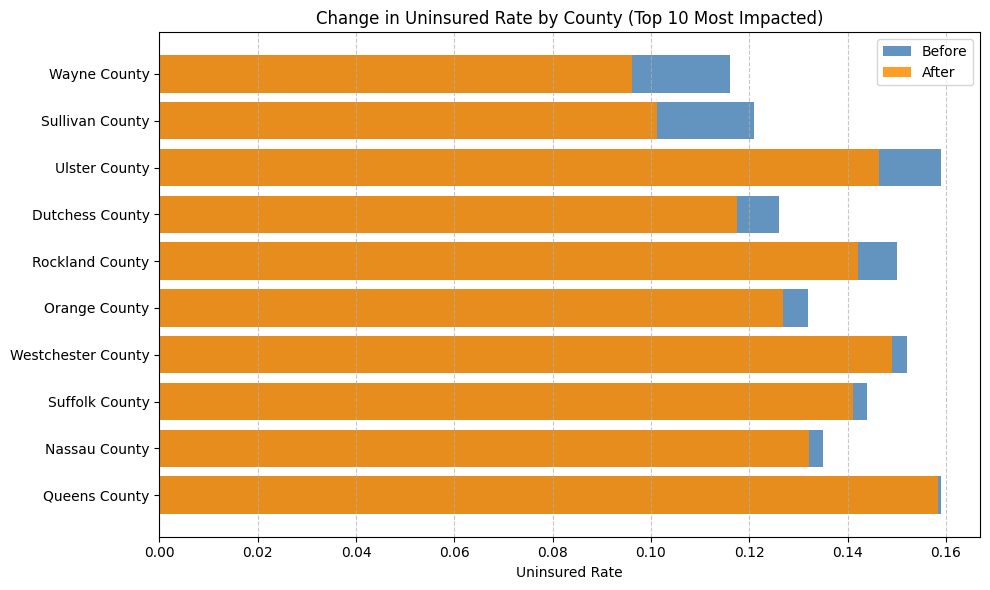

In [8]:
# Clean county names
plot_df = results_df.copy()
plot_df["county"] = plot_df["county"].str.strip()

# Remove blank rows
plot_df = plot_df[plot_df["county"] != ""]

# Compute uninsured rate reduction
plot_df["reduction"] = plot_df["old_pct"] - plot_df["new_pct"]

# Top 10 most impacted counties
plot_df = plot_df.sort_values(by="reduction", ascending=False).head(10)

# Reverse for horizontal bar chart display order
plot_df = plot_df[::-1]

positions = np.arange(len(plot_df))

plt.figure(figsize=(10, 6))

plt.barh(positions, plot_df["old_pct"], label="Before", color="steelblue", alpha=0.85)
plt.barh(positions, plot_df["new_pct"], label="After", color="darkorange", alpha=0.85)

plt.yticks(positions, plot_df["county"])
plt.xlabel("Uninsured Rate")
plt.title("Change in Uninsured Rate by County (Top 10 Most Impacted)")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

In [9]:
# export results to csv
results_df.to_csv('results.csv', index=False)
print('results.csv exported successfully!')

results.csv exported successfully!


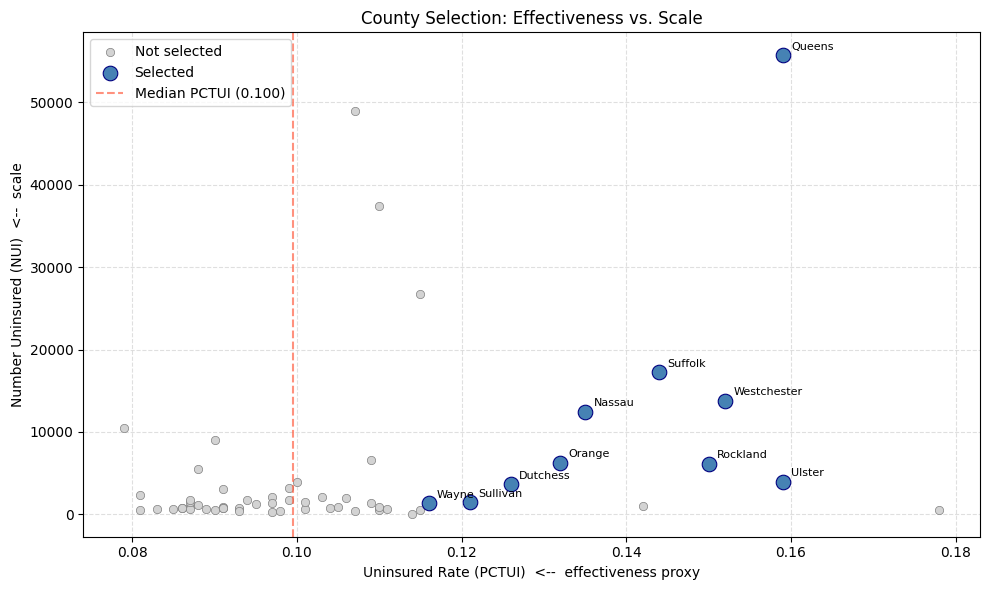

In [10]:
# Decision insight: why were these counties selected?
# Plot all counties by effectiveness (PCTUI) vs. scale (NUI), highlighting selected ones.

selected     = [i for i in counties if y[i].solution_value() > 0.5]
not_selected = [i for i in counties if y[i].solution_value() <= 0.5]

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    [df.loc[i, "PCTUI"] for i in not_selected],
    [df.loc[i, "NUI"] for i in not_selected],
    color="lightgray", edgecolors="gray", linewidths=0.5,
    label="Not selected", zorder=2
)
ax.scatter(
    [df.loc[i, "PCTUI"] for i in selected],
    [df.loc[i, "NUI"] for i in selected],
    color="steelblue", s=110, edgecolors="navy", linewidths=0.8,
    label="Selected", zorder=3
)

for i in selected:
    name = df.loc[i, "county_name"].strip().replace(" County", "")
    ax.annotate(name, (df.loc[i, "PCTUI"], df.loc[i, "NUI"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.axvline(median_pctui, color="tomato", linestyle="--", alpha=0.7,
           label=f"Median PCTUI ({median_pctui:.3f})")

ax.set_xlabel("Uninsured Rate (PCTUI)  <--  effectiveness proxy")
ax.set_ylabel("Number Uninsured (NUI)  <--  scale")
ax.set_title("County Selection: Effectiveness vs. Scale")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [11]:
df.tail(10)

,countyfips,county_name,NUI,PCTUI,NIPR,alpha,capacity,underserved
18793,105,Sullivan County ...,1490,0.121,12334,2.42,123.140496,1
18889,107,Tioga County ...,514,0.081,6311,1.62,63.456790,0
18985,109,Tompkins County ...,1489,0.101,14780,2.02,147.425743,1
19081,111,Ulster County ...,3940,0.159,24757,3.18,247.798742,1
19177,113,Warren County ...,722,0.091,7939,1.82,79.340659,0
19273,115,Washington County ...,723,0.086,8369,1.72,84.069767,0
19369,117,Wayne County ...,1359,0.116,11725,2.32,117.155172,1
19465,119,Westchester County ...,13749,0.152,90260,3.04,904.539474,1
19561,121,Wyoming County ...,448,0.093,4829,1.86,48.172043,0
19657,123,Yates County ...,579,0.178,3255,3.56,32.528090,1


### Decision Insight

The model selects counties that rank highest in $\alpha_i = k \cdot \text{PCTUI}_i$. All selected counties sit **to the right of the median PCTUI line**. Since the budget and per-county cap ($M$) cause most counties to hit their allocation ceiling, the selection problem reduces largely to a ranking by uninsured rate.

The key tradeoff the scatter plot reveals: the model does **not** simply pick the largest counties. Large urban counties (e.g., Bronx, Kings) with moderate uninsured rates are passed over in favor of smaller counties with higher rates, because each dollar of outreach yields more enrollments where the uninsured pool is proportionally larger. The enrollment capacity constraint ($x_i \leq c_i$) enforces a realistic ceiling on this, preventing the model from over-allocating to tiny counties that lack the infrastructure to absorb unlimited outreach dollars in one program cycle.

#### Case Study: Why Yates County Was Not Selected (when cap_rate = 0.20)

Yates County has the **highest uninsured rate** in the dataset ($\text{PCTUI} = 0.178$, $\alpha = 1.78$), yet it does not appear in the optimal solution. This is a direct consequence of the enrollment capacity constraint.

Yates is a small rural county with a limited eligible population. Its enrollment capacity is:

$$c_{\text{Yates}} = \frac{\rho \cdot \text{NUI}_{\text{Yates}}}{\alpha_{\text{Yates}}} = \frac{0.20 \times \text{NUI}_{\text{Yates}}}{3.56} \ll M$$

Because $c_{\text{Yates}} < M = 100$, the county cannot absorb the full budget allocation. Its maximum objective contribution is $\alpha_{\text{Yates}} \cdot c_{\text{Yates}} < 242$, which is less than what Sullivan County contributes at full allocation ($2.42 \times 100 = 242$). The solver therefore prefers Sullivan, a larger county with a slightly lower uninsured rate but no capacity bottleneck.

This illustrates a key modeling insight: **a high effectiveness rate alone does not guarantee selection**. A county must also have sufficient population scale to absorb the minimum viable allocation. Without the capacity constraint, Yates was selected; adding it exposes the real-world operational limit of small counties.

In [12]:
# ── Export for Excel Solver verification ─────────────────────────────────────
# Produces a CSV with every coefficient and bound needed to rebuild the LP in
# Excel Solver and confirm it returns the same optimal solution as Python.

solver_export = df[["county_name", "alpha", "NUI", "capacity", "underserved"]].copy()
solver_export["county_name"] = solver_export["county_name"].str.strip()

# Tightest upper bound on x_i across all three sources: M, NUI cap, capacity cap
solver_export["ub_x"] = solver_export[["NUI", "capacity"]].min(axis=1).clip(upper=M)

# Attach Python optimal solution for side-by-side comparison in Excel
solver_export["opt_x"]             = [round(x[i].solution_value(), 2) for i in counties]
solver_export["opt_y"]             = [int(y[i].solution_value() > 0.5) for i in counties]
solver_export["opt_newly_insured"] = (solver_export["alpha"] * solver_export["opt_x"]).round(1)

# Sort: selected counties first, then by alpha descending
solver_export = solver_export.sort_values(["opt_y", "alpha"], ascending=[False, False])

solver_export.to_csv("excel_solver_input.csv", index=False)

print("excel_solver_input.csv exported.\n")
print("── Model parameters for Excel Solver setup ──────────────────")
print(f"  B  (total budget, $1,000s):         {B}")
print(f"  K  (max counties):                  {K}")
print(f"  M  (max funding per county, $1,000s): {M}")
print(f"  x_min (min funding if selected):    {x_min}")
print(f"  min_underserved:                    {min_underserved}")
print(f"\n── Python optimal objective ─────────────────────────────────")
print(f"  Total newly insured: {sum(df.loc[i,'alpha'] * x[i].solution_value() for i in counties):.1f}")
print("\nTo verify in Excel Solver:")
print("  1. Set x_i and y_i columns as decision variables (y_i = binary)")
print("  2. Objective: SUMPRODUCT(alpha, x_i)")
print("  3. Constraints: sum(x_i)<=B, x_i<=ub_x*y_i, x_i>=x_min*y_i,")
print("                  sum(y_i)<=K, SUMPRODUCT(underserved, y_i)>=min_underserved")

excel_solver_input.csv exported.

── Model parameters for Excel Solver setup ──────────────────
  B  (total budget, $1,000s):         1000
  K  (max counties):                  10
  M  (max funding per county, $1,000s): 100
  x_min (min funding if selected):    20
  min_underserved:                    3

── Python optimal objective ─────────────────────────────────
  Total newly insured: 2788.0

To verify in Excel Solver:
  1. Set x_i and y_i columns as decision variables (y_i = binary)
  2. Objective: SUMPRODUCT(alpha, x_i)
  3. Constraints: sum(x_i)<=B, x_i<=ub_x*y_i, x_i>=x_min*y_i,
                  sum(y_i)<=K, SUMPRODUCT(underserved, y_i)>=min_underserved
